<a href="https://colab.research.google.com/github/luisleonb/Proyecto_M7_ABP/blob/main/Proyect__M7_ABP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Carga y limpieza

In [25]:
import pandas as pd

df = pd.read_csv('Train.csv')
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [26]:
df.Var_1.unique()

array(['Cat_4', 'Cat_6', 'Cat_7', 'Cat_3', 'Cat_1', 'Cat_2', nan, 'Cat_5'],
      dtype=object)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [28]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [29]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [30]:
df.columns

Index(['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1',
       'Segmentation'],
      dtype='object')

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#columnas
categorical = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1', 'Segmentation']
numerical = ['Age', 'Work_Experience', 'Family_Size']

#pipeline variables categóricas
cat_transform = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop= 'if_binary'))
])

#pipeline variables numéricas
num_transform = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy= 'mean')),
    ('scaler', StandardScaler())
])

#se une todo con el colum transformer
preprocessor = ColumnTransformer(
    transformers=[
      ('num', num_transform, numerical),
      ('cat', cat_transform, categorical)
])

#transformación aplicada al dataframe
X_scaled = preprocessor.fit_transform(df)

In [32]:
X_scaled

array([[-1.28462344, -0.50876333,  0.76700122, ...,  0.        ,
         0.        ,  1.        ],
       [-0.32715082,  0.        ,  0.09997238, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.40826831, -0.50876333, -1.2340853 , ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.62636101, -0.50876333, -1.2340853 , ...,  0.        ,
         0.        ,  1.        ],
       [-0.98541324, -0.50876333,  0.76700122, ...,  1.        ,
         0.        ,  0.        ],
       [-0.38699286, -0.81867058,  0.09997238, ...,  1.        ,
         0.        ,  0.        ]])

In [34]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters= 3)

kmeans.fit(X_scaled)

KMeans(n_clusters=3)

In [36]:
df['Cluster'] = kmeans.labels_
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Cluster
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D,1
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A,2
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B,2
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B,2
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A,1


##Reducción de dimensionalidad con PCA

In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components= 15)

X_pca = pca.fit_transform(X_scaled)

print(f"Varianza total explicada: {pca.explained_variance_ratio_.sum():.2%}")

Varianza total explicada: 92.99%


In [19]:
varianza = pca.explained_variance_ratio_
varianza

array([2.42004071e-01, 1.71032429e-01, 1.25743683e-01, 6.77323857e-02,
       4.85782478e-02, 4.41567470e-02, 3.88099828e-02, 3.64077149e-02,
       3.40409699e-02, 2.62337984e-02, 2.49146592e-02, 2.15410302e-02,
       1.77164563e-02, 1.59544093e-02, 1.50817752e-02, 1.30072631e-02,
       1.16642417e-02, 9.67875831e-03, 8.96423907e-03, 7.13113810e-03,
       5.45924889e-03, 4.83902867e-03, 4.58271650e-03, 2.91144550e-03,
       1.81356063e-03, 5.72881005e-18, 3.75521962e-18, 0.00000000e+00,
       0.00000000e+00])

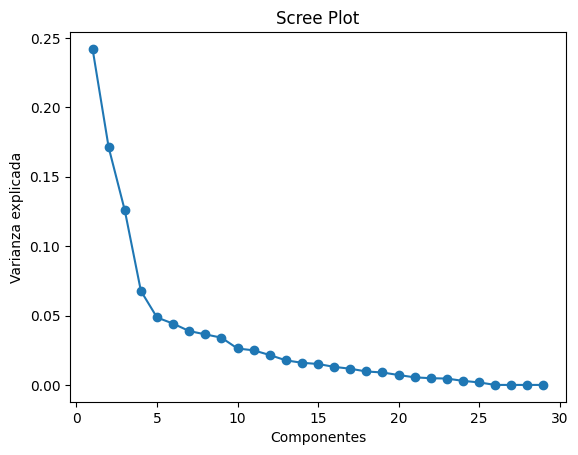

In [20]:
# método visual (método del codo para reducción de dimensionales)
import matplotlib.pyplot as plt

plt.plot(range(1,len(varianza)+1), varianza, marker='o')
plt.xlabel("Componentes")
plt.ylabel("Varianza explicada")
plt.title("Scree Plot")
plt.show()

95% de varianza capturada con 15 componentes

##Aplicacion de t-SNE

In [11]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components= 2)

X_tsne = tsne.fit_transform(X)
